<a href="https://colab.research.google.com/github/Saqib1123f/Predictive-Modeling-of-Indoor-Air-Quality-/blob/main/Topic_02_Jan_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predictive Modeling of Indoor Air Quality**



# **Importing Libraries and Loading file**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv('Indoor Air Pollution Data (1).csv')

# The raw CSV contains many empty 'Unnamed' columns; we keep only the first 9 relevant columns
df = df.iloc[:, :9]
print("Dataset Loaded. Shape:", df.shape)

Dataset Loaded. Shape: (173468, 9)


/tmp/ipython-input-3951559734.py:14: DtypeWarning: Columns (1,4,5,6,7,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Indoor Air Pollution Data (1).csv')


# **Preprocessing and Cleaning**

In [ ]:
# 1. Convert sensor readings to numeric, turning invalid data into NaN
cols_to_fix = ['NO2', 'Temp', 'Pressure', 'Humidity', 'O3']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 2. Fix the Date column
# Replace '|' with a space and convert to datetime.
# errors='coerce' handles values like "0.13" by turning them into NaT
df['Date'] = df['Date'].astype(str).str.replace('|', ' ', regex=False)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# 3. Drop all rows that contain any NaN or NaT (invalid dates or readings)
df = df.dropna()

print("Data Cleaning Complete. Remaining Rows:", len(df))
print(df.head())

Data Cleaning Complete. Remaining Rows: 169932
    NH3   NO2    CO  PM2.5   Temp  Pressure  Humidity     O3  \
0  0.60  0.16  4.01   0.00  33.53    948.26     51.98   7.37   
1  0.62  0.15  4.13   0.39  33.50    948.18     51.53   9.06   
2  0.69  0.14  4.45   0.39  33.36    948.15     50.50  16.47   
3  0.70  0.14  4.52   0.38  32.18    948.14     53.35   9.80   
4  0.72  0.14  4.56   0.40  31.77    948.08     53.70  17.28   

                        Date  
0 2020-11-17 11:20:53.407872  
1 2020-11-17 11:22:41.214724  
2 2020-11-17 11:24:28.546567  
3 2020-11-17 11:26:16.884289  
4 2020-11-17 11:28:19.820781  


# **Exploratry Data Analysis**

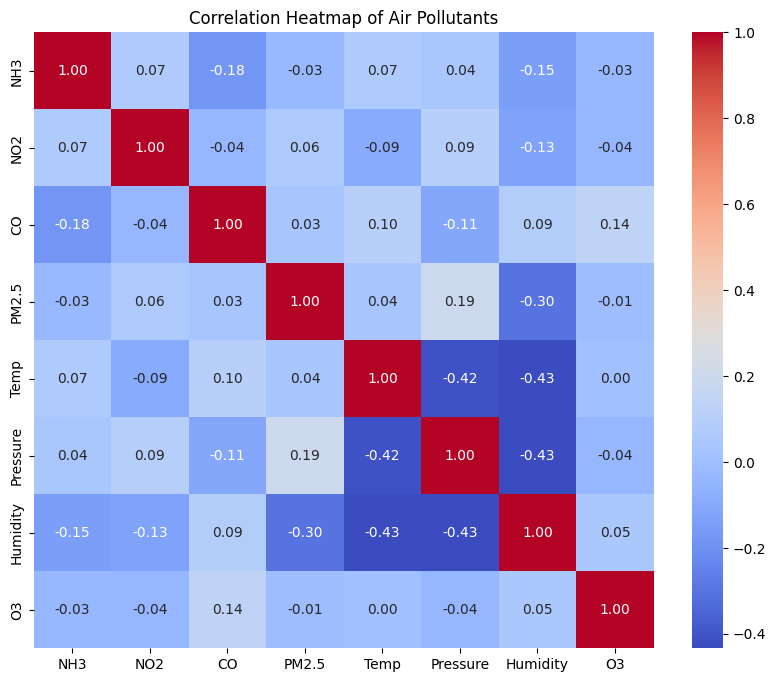

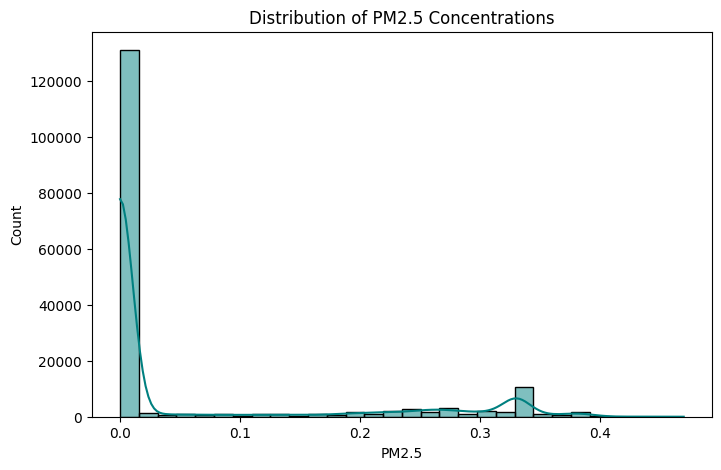

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Air Pollutants")
plt.savefig('correlation_heatmap.png')

# Distribution of Target Variable (PM2.5)
plt.figure(figsize=(8, 5))
sns.histplot(df['PM2.5'], kde=True, bins=30, color='teal')
plt.title("Distribution of PM2.5 Concentrations")
plt.savefig('pm25_distribution.png')

In [ ]:
# Features (X) and Target (y)
X = df[['NH3', 'NO2', 'CO', 'Temp', 'Pressure', 'Humidity', 'O3']]
y = df['PM2.5']

# Sample 5000 rows for faster processing
X_sample = X.sample(5000, random_state=42)
y_sample = y.loc[X_sample.index]

# Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42)

# Scale data (crucial for SVR and KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Prepared for Modeling.")

Data Prepared for Modeling.


# **Model Training**

## **BASIC Machine Learning Model**

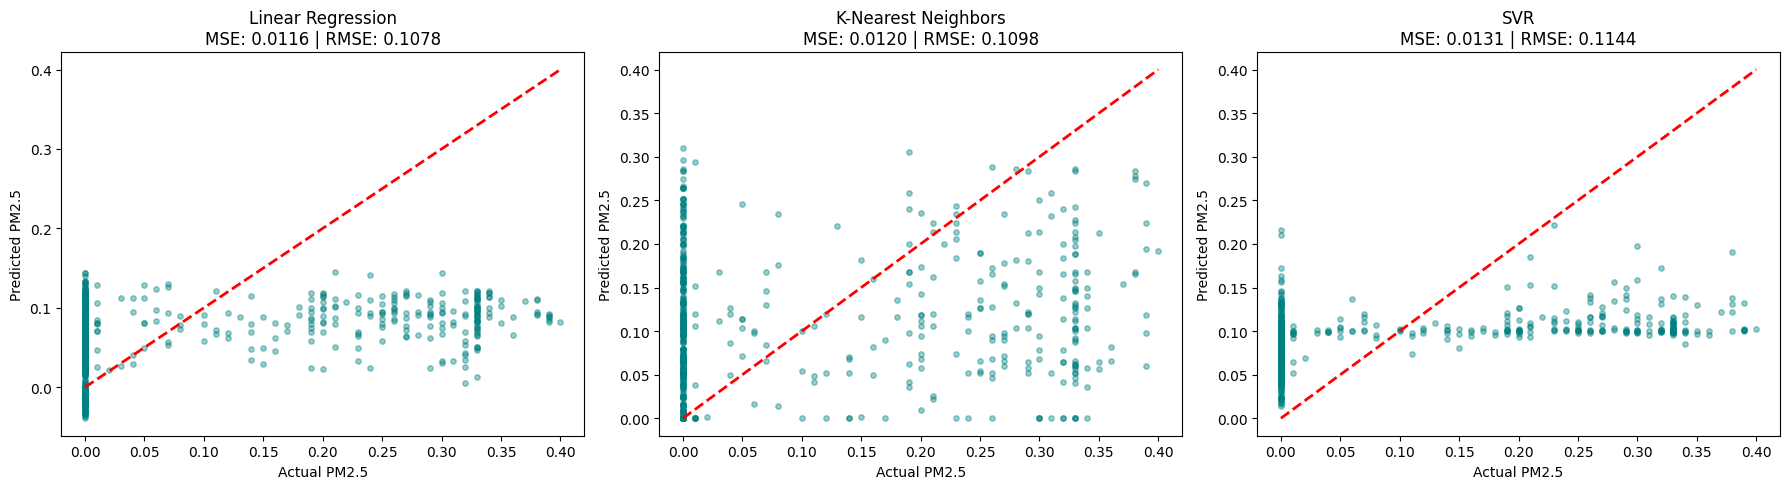


Model Evaluation Indicators:
              Model      MSE     RMSE      MAE         MAPE
  Linear Regression 0.011612 0.107758 0.083023 1.925961e+14
K-Nearest Neighbors 0.012046 0.109754 0.067468 1.479342e+14
                SVR 0.013090 0.114411 0.102934 3.016201e+14


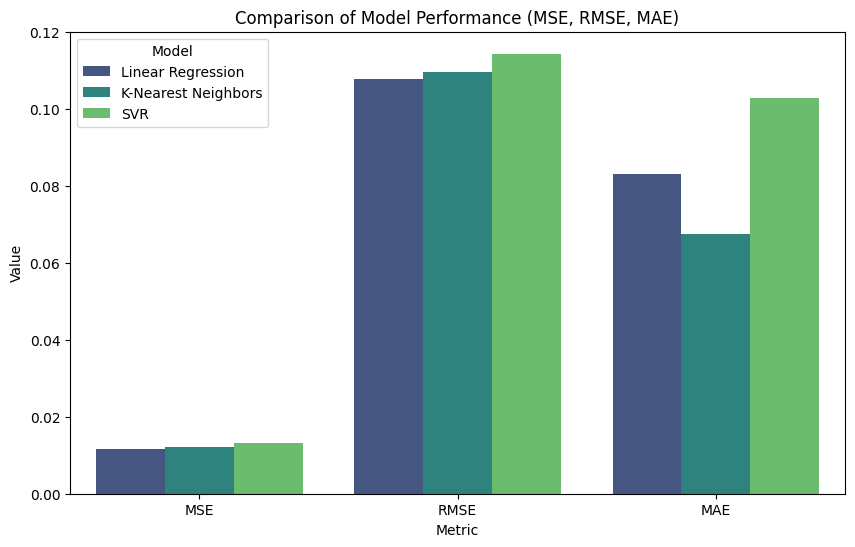

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# 1. Initialize the models
models = {
    "Linear Regression": LinearRegression(),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    "SVR": SVR(kernel='rbf')
}

# 2. Storage for results and visualization setup
results_list = []
plt.figure(figsize=(18, 5))

for i, (name, model) in enumerate(models.items(), 1):
    # Train and predict
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    # Calculate requested indicators
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    mape = mean_absolute_percentage_error(y_test, preds) # Mean Absolute Percentage Error

    # Store results
    results_list.append({
        'Model': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    })

    # Plotting: Actual vs Predicted scatter plots
    plt.subplot(1, 3, i)
    plt.scatter(y_test, preds, alpha=0.4, s=15, color='teal')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.title(f"{name}\nMSE: {mse:.4f} | RMSE: {rmse:.4f}")
    plt.xlabel("Actual PM2.5")
    plt.ylabel("Predicted PM2.5")

plt.tight_layout()
plt.savefig('actual_vs_predicted_grid.png')
plt.show()

# 3. Create and display the results table
results_df = pd.DataFrame(results_list)
print("\nModel Evaluation Indicators:")
print(results_df.to_string(index=False))

# 4. Plotting: Comparative Bar Chart for MSE, RMSE, and MAE
# We exclude MAPE from the bar chart visualization because its scale is too large (due to zero-values)
# which would make the other bars invisible.
results_viz = results_df.drop(columns=['MAPE']).melt(id_vars='Model', var_name='Metric', value_name='Value')

plt.figure(figsize=(10, 6))
sns.barplot(data=results_viz, x='Metric', y='Value', hue='Model', palette='viridis')
plt.title("Comparison of Model Performance (MSE, RMSE, MAE)")
plt.ylabel("Value")
plt.savefig('updated_metrics_comparison.png')
plt.show()

## **Deep Learning: LSTM Training and Evaluation**


Training Deep Learning Model (LSTM)...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1912/1912 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 0.0238 - val_loss: 0.0878
Epoch 2/10
1912/1912 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.0139 - val_loss: 0.0667
Epoch 3/10
1912/1912 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 0.0135 - val_loss: 0.0434
Epoch 4/10
1912/1912 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 0.0133 - val_loss: 0.0251
Epoch 5/10
1912/1912 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 0.0132 - val_loss: 0.0197
Epoch 6/10
1912/1912 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 0.0131 - val_loss: 0.0253
Epoch 7/10
1912/1912 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 0.0131 - val_loss: 0.0209
Epoch 8/10
1912/1912 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.0130 - val_loss: 0.0269
Epoch 9/10
1912/1912 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.0130 - val_loss: 0.0163
Epoch 10/10
1912/1912 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 0.0130 - val_loss: 0.0197
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

--- LSTM Model Performance ---
MSE:  0.0041
RMSE: 0.0642
MAE:  0.0477
MAPE:

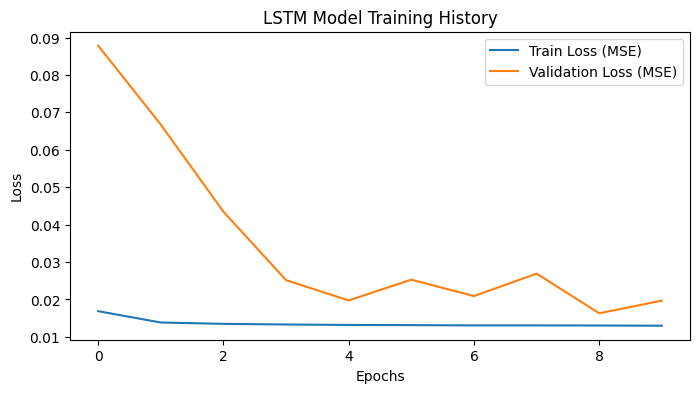

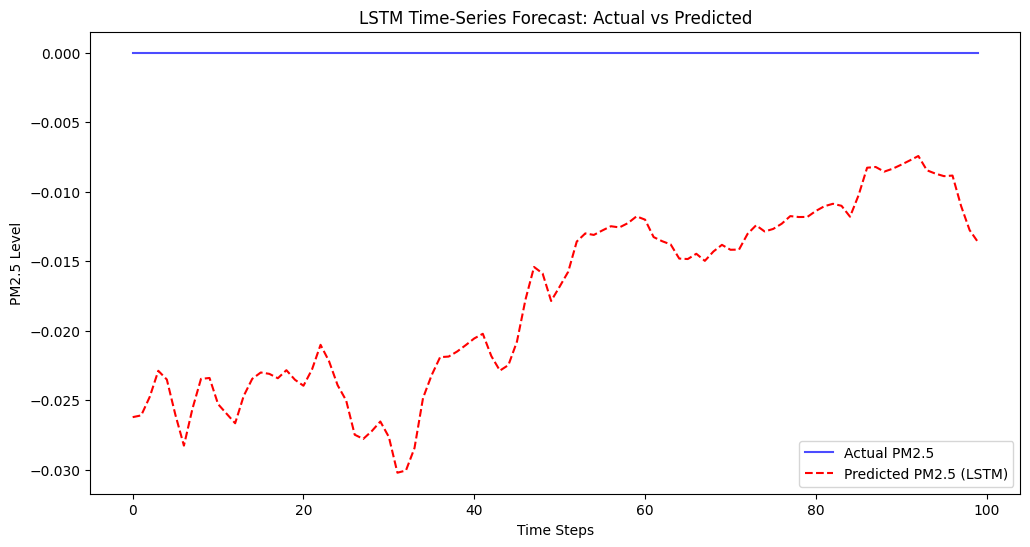

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# 1. Prepare Sequences for LSTM
# We use a 'window' of 10 past readings to predict the next PM2.5 value
def create_sequences(data, target, window_size=10):
    X_seq, y_seq = [], []
    for i in range(len(data) - window_size):
        X_seq.append(data[i:(i + window_size)])
        y_seq.append(target[i + window_size])
    return np.array(X_seq), np.array(y_seq)

# Scale all features and prepare the dataset
full_data_scaled = scaler.transform(X)
window_size = 10
X_lstm, y_lstm = create_sequences(full_data_scaled, y.values, window_size)

# Split into train and test sets chronologically (80/20 split)
split = int(0.8 * len(X_lstm))
X_train_dl, X_test_dl = X_lstm[:split], X_lstm[split:]
y_train_dl, y_test_dl = y_lstm[:split], y_lstm[split:]

# 2. Build the LSTM Model
model_dl = Sequential([
    LSTM(50, activation='relu', input_shape=(window_size, X_train_dl.shape[2])),
    Dropout(0.2),
    Dense(1)
])

model_dl.compile(optimizer='adam', loss='mse')

# 3. Train the Model
print("\nTraining Deep Learning Model (LSTM)...")
history = model_dl.fit(
    X_train_dl, y_train_dl,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# 4. Evaluate and Calculate Indicators
dl_preds = model_dl.predict(X_test_dl)

# Calculate indicators
dl_mse = mean_squared_error(y_test_dl, dl_preds)
dl_rmse = np.sqrt(dl_mse)
dl_mae = mean_absolute_error(y_test_dl, dl_preds)
dl_mape = mean_absolute_percentage_error(y_test_dl, dl_preds)

print("\n--- LSTM Model Performance ---")
print(f"MSE:  {dl_mse:.4f}")
print(f"RMSE: {dl_rmse:.4f}")
print(f"MAE:  {dl_mae:.4f}")
print(f"MAPE: {dl_mape:.4e}") # Using scientific notation as MAPE can be very high due to zero values

# 5. Visualizations
# A. Training History Plot
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('LSTM Model Training History')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('lstm_training_history.png')

# B. Forecast Plot: Actual vs Predicted (Sample of 100 points)
plt.figure(figsize=(12, 6))
plt.plot(y_test_dl[:100], label='Actual PM2.5', color='blue', alpha=0.7)
plt.plot(dl_preds[:100], label='Predicted PM2.5 (LSTM)', color='red', linestyle='--')
plt.title('LSTM Time-Series Forecast: Actual vs Predicted')
plt.xlabel('Time Steps')
plt.ylabel('PM2.5 Level')
plt.legend()
plt.savefig('lstm_forecast_comparison.png')

print("\nDeep Learning block completed and plots saved.")

## **Statistical Baseline Model: ARIMA**


Fitting ARIMA Model...

--- ARIMA Model Performance ---
MSE:  0.0299
RMSE: 0.1729
MAE:  0.1269
MAPE: 5.6300e+13

ARIMA block completed and plot saved.


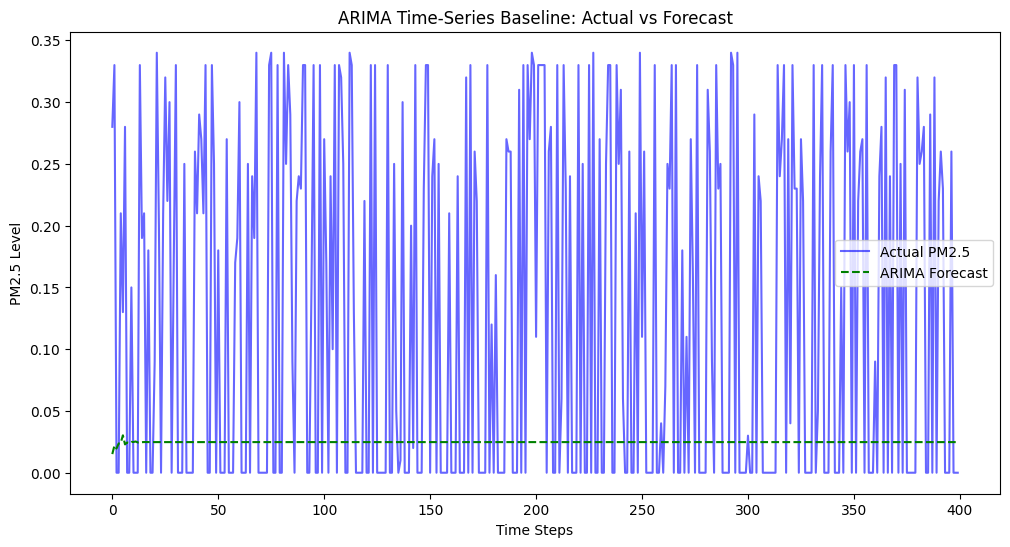

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# 1. Prepare the Data
# Use the PM2.5 series. We take a continuous slice of the data for time-series consistency.
# Using a sample of 2000 points for demonstration to keep it "simple" and fast.
ts_data = df['PM2.5'].values[:2000]

# Split into train and test sets (80/20 split)
train_size = int(len(ts_data) * 0.8)
train_ts, test_ts = ts_data[0:train_size], ts_data[train_size:len(ts_data)]

# 2. Build and Fit the ARIMA Model
# Order (p,d,q): (5,1,0) is a common starting point for air quality data
print("\nFitting ARIMA Model...")
model_arima = ARIMA(train_ts, order=(5, 1, 0))
model_arima_fit = model_arima.fit()

# 3. Forecast
# We forecast the length of the test set
arima_preds = model_arima_fit.forecast(steps=len(test_ts))

# 4. Calculate Indicators
arima_mse = mean_squared_error(test_ts, arima_preds)
arima_rmse = np.sqrt(arima_mse)
arima_mae = mean_absolute_error(test_ts, arima_preds)
arima_mape = mean_absolute_percentage_error(test_ts, arima_preds)

print("\n--- ARIMA Model Performance ---")
print(f"MSE:  {arima_mse:.4f}")
print(f"RMSE: {arima_rmse:.4f}")
print(f"MAE:  {arima_mae:.4f}")
print(f"MAPE: {arima_mape:.4e}")

# 5. Visualizations
plt.figure(figsize=(12, 6))
plt.plot(test_ts, label='Actual PM2.5', color='blue', alpha=0.6)
plt.plot(arima_preds, label='ARIMA Forecast', color='green', linestyle='--')
plt.title('ARIMA Time-Series Baseline: Actual vs Forecast')
plt.xlabel('Time Steps')
plt.ylabel('PM2.5 Level')
plt.legend()
plt.savefig('arima_forecast_comparison.png')

print("\nARIMA block completed and plot saved.")

# **Feature Importance**

/tmp/ipython-input-18378537.py:14: DtypeWarning: Columns (1,4,5,6,7,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Indoor Air Pollution Data (1).csv')
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/tmp/ipython-input-18378537.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=rf_importance, palette='viridis')
/tmp/ipython-input-18378537.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same eff

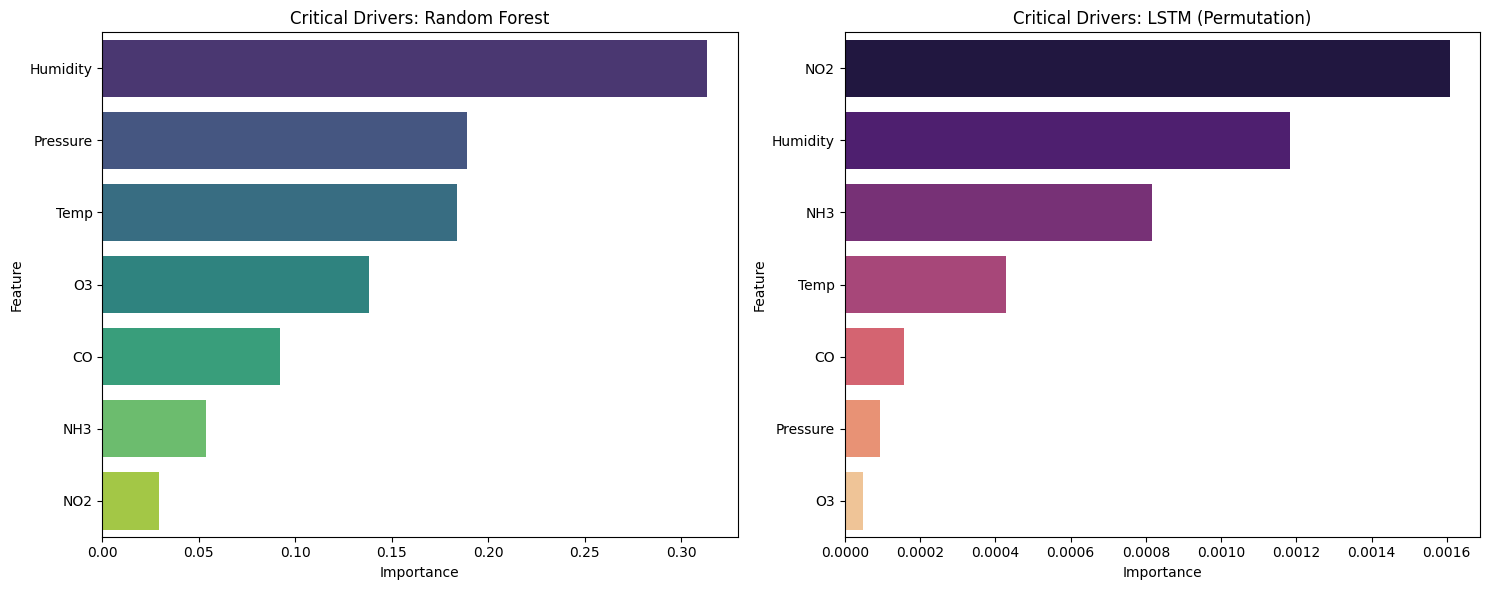


Analysis for RQ3:
- According to Random Forest, the most critical driver is: Humidity
- According to LSTM, the most critical driver is: NO2


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. DATA LOADING AND CLEANING
df = pd.read_csv('Indoor Air Pollution Data (1).csv')
df = df.iloc[:, :9]

# Clean numeric columns
cols_to_fix = ['NO2', 'Temp', 'Pressure', 'Humidity', 'O3']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Clean Date and drop invalid rows
df['Date'] = df['Date'].astype(str).str.replace('|', ' ', regex=False)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna()

# Select Features and Target
features = ['NH3', 'NO2', 'CO', 'Temp', 'Pressure', 'Humidity', 'O3']
X = df[features]
y = df['PM2.5']

# 2. RANDOM FOREST FEATURE IMPORTANCE (Simple ML Baseline)
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_rf, y_train_rf)

rf_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 3. LSTM PERMUTATION IMPORTANCE (Deep Learning Context)
# Scale and Prepare Sequences
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

def create_sequences(data, target, window_size=10):
    X_seq, y_seq = [], []
    for i in range(len(data) - window_size):
        X_seq.append(data[i:(i + window_size)])
        y_seq.append(target[i + window_size])
    return np.array(X_seq), np.array(y_seq)

# Sample 5000 rows for sequence modeling efficiency
X_lstm, y_lstm = create_sequences(X_scaled[:5000], y.values[:5000], window_size=10)
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(X_lstm, y_lstm, test_size=0.2, random_state=42)

# Build and Train a quick LSTM
model_dl = Sequential([
    LSTM(32, activation='relu', input_shape=(10, len(features))),
    Dense(1)
])
model_dl.compile(optimizer='adam', loss='mse')
model_dl.fit(X_train_dl, y_train_dl, epochs=5, batch_size=32, verbose=0)

# Calculate Permutation Importance for LSTM
baseline_mse = mean_squared_error(y_test_dl, model_dl.predict(X_test_dl, verbose=0))
lstm_importances = []

for i, feature in enumerate(features):
    X_test_permuted = X_test_dl.copy()
    # Shuffle the values of one feature to break its relationship with target
    flat_feature = X_test_permuted[:, :, i].flatten()
    np.random.shuffle(flat_feature)
    X_test_permuted[:, :, i] = flat_feature.reshape(X_test_dl.shape[0], 10)

    permuted_mse = mean_squared_error(y_test_dl, model_dl.predict(X_test_permuted, verbose=0))
    lstm_importances.append(permuted_mse - baseline_mse)

lstm_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': lstm_importances
}).sort_values(by='Importance', ascending=False)

# 4. VISUALIZATION OF DRIVERS
plt.figure(figsize=(15, 6))

# Plot Random Forest Importance
plt.subplot(1, 2, 1)
sns.barplot(x='Importance', y='Feature', data=rf_importance, palette='viridis')
plt.title('Critical Drivers: Random Forest')

# Plot LSTM Permutation Importance
plt.subplot(1, 2, 2)
sns.barplot(x='Importance', y='Feature', data=lstm_importance_df, palette='magma')
plt.title('Critical Drivers: LSTM (Permutation)')

plt.tight_layout()
plt.savefig('rq3_feature_importance_comparison.png')
plt.show()

# Final Determination
top_rf = rf_importance.iloc[0]['Feature']
top_lstm = lstm_importance_df.iloc[0]['Feature']

print(f"\nAnalysis for RQ3:")
print(f"- According to Random Forest, the most critical driver is: {top_rf}")
print(f"- According to LSTM, the most critical driver is: {top_lstm}")

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_8
Received: inputs=['Tensor(shape=(50, 10, 7))']
  warnings.warn(msg)


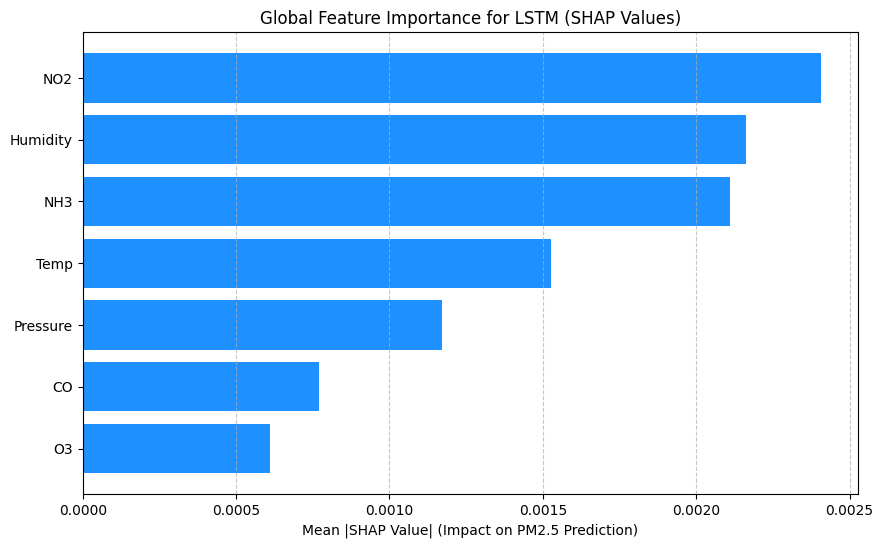


SHAP Analysis Results:
NO2: 0.002406
Humidity: 0.002164
NH3: 0.002111
Temp: 0.001528
Pressure: 0.001170
CO: 0.000772
O3: 0.000610

Conclusion: SHAP analysis identifies 'NO2' as the most critical driver of PM2.5 variations.


In [ ]:
# Note: You must run !pip install shap in your local environment first
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare Background Data
# SHAP needs a 'background' dataset to learn the baseline output of the model.
# We take a small random sample from the training set for speed.
background = X_train_dl[np.random.choice(X_train_dl.shape[0], 100, replace=False)]

# 2. Initialize the Explainer
# GradientExplainer is well-suited for Keras/TensorFlow LSTM models.
explainer = shap.GradientExplainer(model_dl, background)

# 3. Compute SHAP Values
# We explain the predictions for a subset of the test data.
# This results in a 3D array: (samples, time_steps, features)
test_sample = X_test_dl[:50]
shap_values = explainer.shap_values(test_sample)

# 4. Process 3D SHAP Values for Visualization
# shap_values[0] shape is (50, 10, 7).
# To get global importance, we take the mean absolute value across samples and time-steps.
if isinstance(shap_values, list):
    shap_val_array = shap_values[0]
else:
    shap_val_array = shap_values

# Mean importance per feature
mean_abs_shap = np.mean(np.abs(shap_val_array), axis=(0, 1)).flatten() # Flatten to 1D array

# 5. Create Importance DataFrame
feature_names = ['NH3', 'NO2', 'CO', 'Temp', 'Pressure', 'Humidity', 'O3']
shap_df = pd.DataFrame({
    'Feature': feature_names,
    'SHAP Importance': mean_abs_shap
}).sort_values(by='SHAP Importance', ascending=False)

# 6. Visualize
plt.figure(figsize=(10, 6))
plt.barh(shap_df['Feature'], shap_df['SHAP Importance'], color='dodgerblue')
plt.gca().invert_yaxis() # Highest importance at the top
plt.title('Global Feature Importance for LSTM (SHAP Values)')
plt.xlabel('Mean |SHAP Value| (Impact on PM2.5 Prediction)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig('lstm_shap_analysis.png')
plt.show()

# Final Answer for RQ3
print("\nSHAP Analysis Results:")
for index, row in shap_df.iterrows():
    print(f"{row['Feature']}: {row['SHAP Importance']:.6f}")

top_driver = shap_df.iloc[0]['Feature']
print(f"\nConclusion: SHAP analysis identifies '{top_driver}' as the most critical driver of PM2.5 variations.")